In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader,ConcatDataset
from LSTM_databuilder import AssistSequenceDataset
from LSTM_model_train import AssistLSTM
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path(r"C:\Users\loy49\Desktop\REPO\LSTM_HRC")

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
    
from data_proc_2d.app.build_norm_dataset import NormDatasetBuilder


In [163]:
test_notes = "Step only test"

In [7]:
#device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### hyper param short epoch test

In [30]:
# #training config
# epochs = 60
# batch_size = 32
# lr = 3e-4

# #sliding window config
# window_size = 160
# stride = 30
# predict_offset = 0
# num_workers = 4

# mode = "seq2one"  # "seq2one" or "seq2seq"

# hidden_layer = 64

# train_shuffle = False


### hyper param optimization

In [17]:
#training config
epochs = 60
batch_size = 32
lr = 1e-4

#sliding window config
window_size = 160
stride = 30
predict_offset = 0
num_workers = 4

mode = "seq2one"  # "seq2one" or "seq2seq"

hidden_layer = 64

train_shuffle = True

dropout = 0.2
num_layers = 1

weighted_loss = True

weight_decay = 0.01

## load training data

In [15]:
npz_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\train\norm"
npz_paths = [os.path.join(npz_dir, f) for f in os.listdir(npz_dir) if f.endswith(".npz")]
datasets = []
print(len(npz_paths))

75


## load norm.npz

In [13]:

norm_stats = np.load(r"C:\Users\loy49\Desktop\REPO\LSTM_HRC\data_proc_3d\dataset\norm_2026-09-23.npz", allow_pickle=True)  

## load & norm val data

In [168]:
val_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\val\raw"
val_paths = [os.path.join(val_dir, f) for f in os.listdir(val_dir) if f.endswith(".pt")]

npz_val_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\val\norm"

In [169]:
if len(os.listdir(npz_val_dir)) <=1:

    builder = NormDatasetBuilder(norm_stats)

    #norm val dataset
    for val_path in val_paths:
        out_path = os.path.join(npz_val_dir, os.path.basename(val_path).replace(".pt", "_norm.npz"))
        builder.build_dataset(val_path,out_path)
    print("Validation dataset normalization complete.")

In [170]:

npz_val_paths = [os.path.join(npz_val_dir, f) for f in os.listdir(npz_val_dir) if f.endswith(".npz")]
print(len(npz_val_paths))

9


## load & norm test data

In [12]:
test_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\test\raw"
test_paths = [os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.endswith(".pt")]

npz_test_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\test\norm"

In [172]:
if len(os.listdir(npz_test_dir)) <=1:
    builder = NormDatasetBuilder(norm_stats)

    #norm test dataset
    for test_path in test_paths:
        out_path = os.path.join(npz_test_dir, os.path.basename(test_path).replace(".pt", "_norm.npz"))
        builder.build_dataset(test_path,out_path)
    print("Test dataset normalization complete.")

    
npz_test_paths = [os.path.join(npz_test_dir, f) for f in os.listdir(npz_test_dir) if f.endswith(".npz")]
print(len(npz_test_paths))

9


In [173]:
FEATURE_KEYS = [
    'joint_speed', 
    'joint_acceleration', 
    'joint_velocity_x', 
    'joint_velocity_y', 
    'joint_velocity_z', 
    'joint_acceleration_x', 
    'joint_acceleration_y', 
    'joint_acceleration_z', 
    'position_x_relative_to_pelvis', 
    'position_y_relative_to_pelvis', 
    'position_z_relative_to_pelvis', 
    'polar_azimuth', 
    'polar_elevation', 
    'joint_angles', 
    'ratios', 
    'distance_from_center'
]

# Change the selected features here!!

In [19]:
x_keys = [
         'distance_from_center',
         'position_x_relative_to_pelvis', 
         'position_y_relative_to_pelvis', 
         'position_z_relative_to_pelvis', 
         'joint_angles', 
         'polar_elevation'
        ]

## training dataset

In [20]:
for npz_path in npz_paths:
    print(f"Loading dataset from {npz_path}...")
    dataset = AssistSequenceDataset(npz_path=npz_path,
                                    window_size=window_size,
                                    stride=stride,
                                    predict_offset=predict_offset,
                                    mode= mode,
                                    feature_keys=x_keys)
    datasets.append(dataset)
    
full_dataset = ConcatDataset(datasets)

loader = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=train_shuffle, num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=False)
for x, y in loader:
    step = y["step"]
    progress = y["progress"]
    print("Batch X shape:", x.shape)  # should be [batch_size, window_size, feature_dim]
    print("Batch Y-step shape:", step.shape)  # should be [batch_size]
    print("Batch Y-progress shape:", progress.shape)  # should be [batch_size]
    break

Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\train\norm\features__cam-05_uid-14_take-01_norm.npz...
Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\train\norm\features__cam-05_uid-14_take-02_norm.npz...
Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\train\norm\features__cam-06_uid-14_take-01_norm.npz...
Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\train\norm\features__cam-06_uid-14_take-02_norm.npz...
Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\train\norm\features_

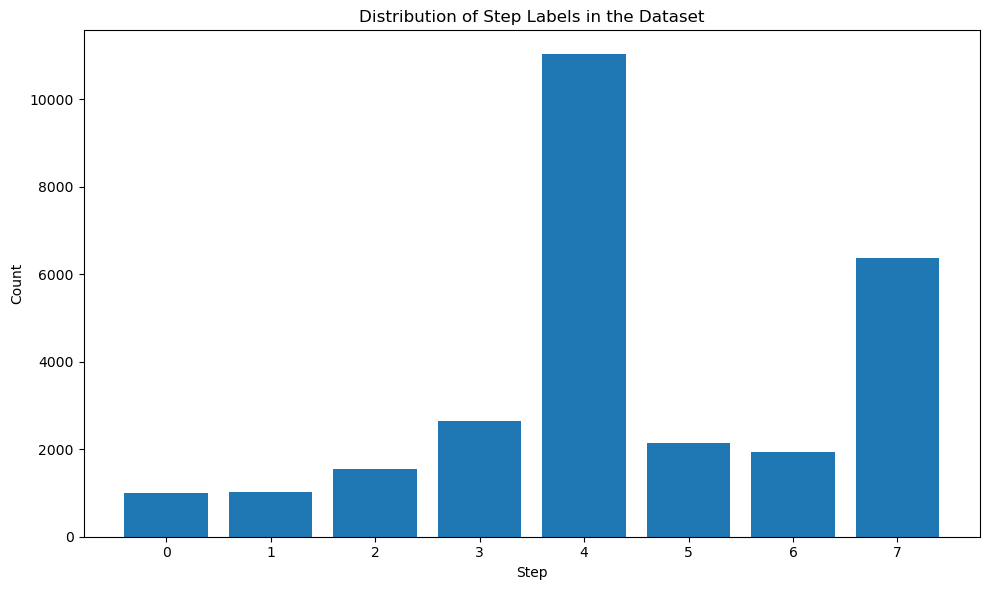

Counter({4: 11024, 7: 6369, 3: 2649, 5: 2135, 6: 1948, 2: 1537, 1: 1032, 0: 998})


In [88]:
from collections import Counter

targets = []

for i in range(len(full_dataset)):
    _, y = full_dataset[i]
    targets.append(int(y["step"]))

counts = Counter(targets)

#plot the counts
plt.figure(figsize=(10, 6))
plt.bar(counts.keys(), counts.values())
plt.xlabel("Step")
plt.ylabel("Count")
plt.title("Distribution of Step Labels in the Dataset")

plt.tight_layout()
plt.show()

print(counts)

## val dataset

In [176]:
val_datasets = []
for npz_val_path in npz_val_paths:
    print(f"Loading validation dataset from {npz_val_path}...")
    val_dataset = AssistSequenceDataset(npz_path=npz_val_path,
                                        window_size=window_size,
                                        stride=stride,
                                        predict_offset=predict_offset,
                                        mode=mode,
                                        feature_keys=x_keys)
    val_datasets.append(val_dataset)    

fulldataset_val = ConcatDataset(val_datasets)

val_loader = DataLoader(ConcatDataset(val_datasets), batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=False)

Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\val\norm\features__cam-05_uid-01_take-02_norm.npz...
Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\val\norm\features__cam-05_uid-15_take-01_norm.npz...
Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\val\norm\features__cam-05_uid-15_take-02_norm.npz...
Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\val\norm\features__cam-06_uid-01_take-02_norm.npz...
Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\cei

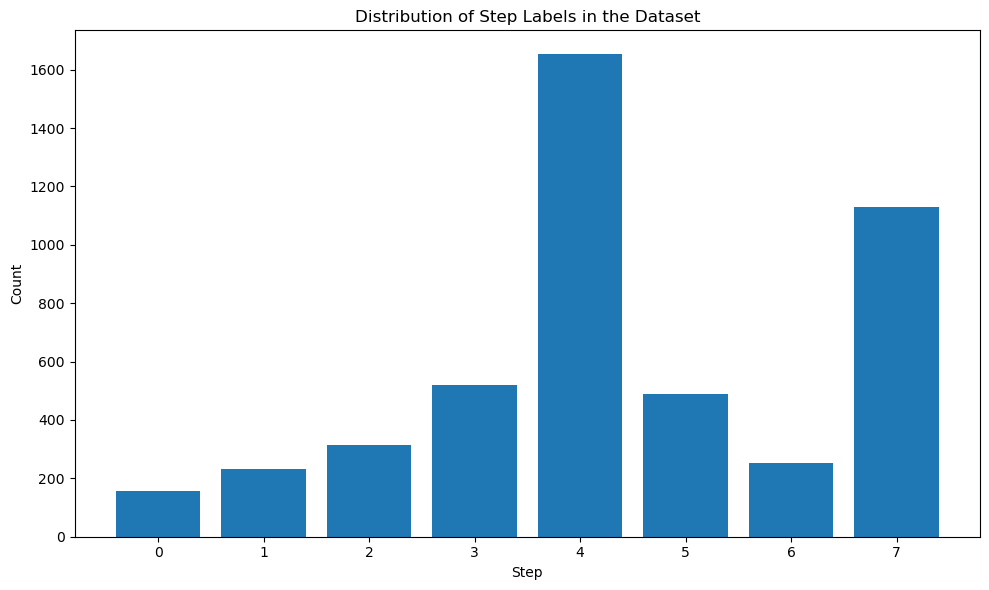

Counter({4: 1652, 7: 1131, 3: 520, 5: 489, 2: 315, 6: 254, 1: 233, 0: 157})


In [90]:
from collections import Counter

targets = []

for i in range(len(fulldataset_val)):
    _, y = fulldataset_val[i]
    targets.append(int(y["step"]))

counts = Counter(targets)

#plot the counts
plt.figure(figsize=(10, 6))
plt.bar(counts.keys(), counts.values())
plt.xlabel("Step")
plt.ylabel("Count")
plt.title("Distribution of Step Labels in the Dataset")

plt.tight_layout()
plt.show()

print(counts)

## test dataset

In [177]:
test_datasets = []
for npz_test_path in npz_test_paths:
    print(f"Loading test dataset from {npz_test_path}...")
    test_dataset = AssistSequenceDataset(npz_path=npz_test_path,
                                         window_size=window_size,
                                         stride=stride,
                                         predict_offset=predict_offset,
                                         mode=mode,
                                         feature_keys=x_keys)
    test_datasets.append(test_dataset)    

fulldataset_test = ConcatDataset(test_datasets)
test_loader = DataLoader(ConcatDataset(test_datasets), batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=False)

Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\test\norm\features__cam-06_uid-02_take-01_norm.npz...
Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\test\norm\features__cam-06_uid-02_take-02_norm.npz...
Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\test\norm\features__cam-06_uid-02_take-03-1_norm.npz...
Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\test\norm\features__cam-07_uid-02_take-01_norm.npz...
Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_

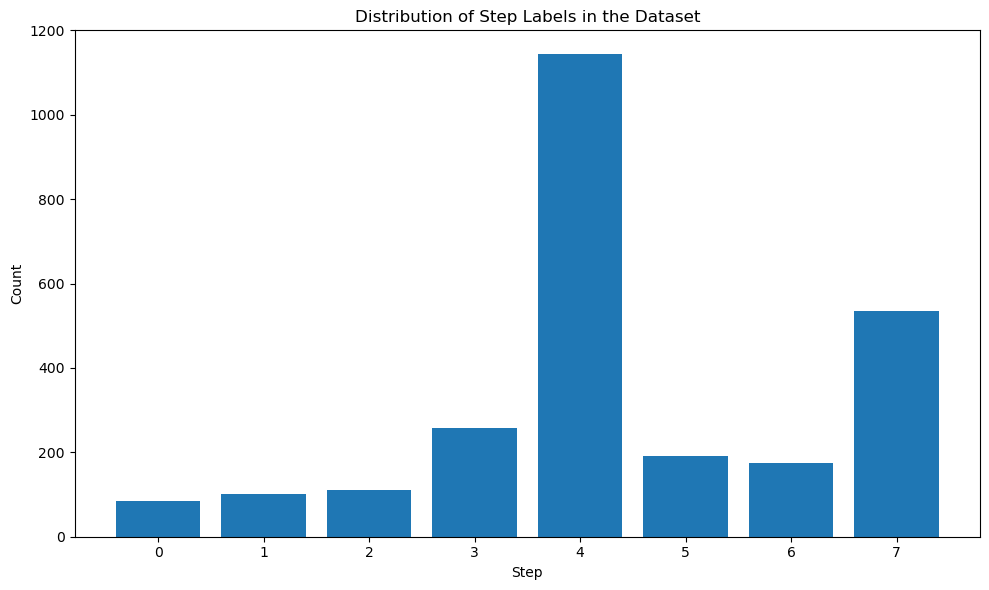

Counter({4: 1143, 7: 536, 3: 258, 5: 192, 6: 174, 2: 111, 1: 102, 0: 84})


In [93]:
from collections import Counter

targets = []

for i in range(len(fulldataset_test)):
    _, y = fulldataset_test[i]
    targets.append(int(y["step"]))

counts = Counter(targets)

#plot the counts
plt.figure(figsize=(10, 6))
plt.bar(counts.keys(), counts.values())
plt.xlabel("Step")
plt.ylabel("Count")
plt.title("Distribution of Step Labels in the Dataset")

plt.tight_layout()
plt.show()

print(counts)

### model

In [178]:
# get one batch to infer feature_dim and num_types
x_sample, y_sample = next(iter(loader))

input_dim = x_sample.shape[-1]
num_mistakes = 2
num_steps = max(int(d.step.max()) for d in datasets) + 1

print("Input dim:", input_dim)
print("Num steps:", num_steps)
print("X shape:", x_sample.shape)
print("Step shape:", y_sample["step"].shape)
print("Step values:", y_sample["step"].unique())
print("Progress shape:", y_sample["progress"].shape)
print("Progress values:", y_sample["progress"].unique())
print("Mistakes shape:", y_sample["mistake"].shape)
print("Task mistakes:", y_sample["mistake"].unique())

model = AssistLSTM(
    input_dim=input_dim,
    hidden_dim=hidden_layer,
    num_steps=num_steps,
    dropout=dropout,
    num_layers=num_layers,
    num_mistakes=num_mistakes,
).to(device)

Input dim: 89
Num steps: 8
X shape: torch.Size([32, 160, 89])
Step shape: torch.Size([32])
Step values: tensor([0, 2, 3, 4, 5, 6, 7])
Progress shape: torch.Size([32])
Progress values: tensor([0.0000, 0.0094, 0.0127, 0.0721, 0.1762, 0.3843, 0.4566, 0.4652, 0.5227,
        0.6480, 0.7742, 0.8358, 0.8417, 0.8585, 0.8626, 0.9160, 0.9602, 0.9842])
Mistakes shape: torch.Size([32])
Task mistakes: tensor([0, 1])


In [179]:
x_val_sample, y_val_sample = next(iter(val_loader))
print("progress value", y_val_sample["progress"].unique())
print("step value", y_val_sample["step"].unique())

progress value tensor([0.0000, 0.0073, 0.0171, 0.0735, 0.1040, 0.1153, 0.1935, 0.2449, 0.2715,
        0.3487, 0.4177, 0.5203, 0.6004, 0.6897, 0.7710, 0.8383, 0.8476, 0.8847,
        0.9075, 0.9474, 0.9878, 0.9984])
step value tensor([0, 1, 2, 7])


In [180]:

optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

# Count task_id targets of training windows, not all raw frames.
if mode != "seq2one":
    raise ValueError("Task class weighting currently requires seq2one mode.")
step_class_counts = np.zeros(num_steps, dtype=np.int64)
for dataset in datasets:
    target_indices = (np.asarray(dataset.indices, dtype=np.int64)
                      + dataset.window_size - 1 + dataset.predict_offset)
    targets = dataset.step[target_indices].astype(np.int64)
    step_class_counts += np.bincount(targets, minlength=num_steps)

if np.any(step_class_counts == 0):
    raise ValueError(f"No training windows for task IDs: {np.flatnonzero(step_class_counts == 0).tolist()}")

# Square-root inverse frequency: average training-sample weight is 1.
step_weights = 1.0 / np.sqrt(step_class_counts)


step_weights /= np.average(step_weights, weights=step_class_counts)
step_class_weights = torch.tensor(
    step_weights,
    dtype=torch.float32, device=device,
)
print("Task ID window counts:", step_class_counts.tolist())
print("Task ID class weights:", step_class_weights.tolist())

# Average weighted samples explicitly so single-class batches retain their weight.
step_ce_loss = nn.CrossEntropyLoss(weight=step_class_weights, reduction="none")
# step_ce_loss = nn.CrossEntropyLoss()
ce_loss = nn.CrossEntropyLoss()  # Mistake classification remains unweighted.
mse_loss = nn.MSELoss()

#should adjust later
lambda_step = 1.0
lambda_progress = 1.0
lambda_mistake = 1.0


Task ID window counts: [998, 1032, 1537, 2649, 11024, 2135, 1948, 6369]
Task ID class weights: [2.0407657623291016, 2.006866931915283, 1.6444530487060547, 1.2526144981384277, 0.6140288710594177, 1.3952739238739014, 1.460709810256958, 0.8078352212905884]


In [21]:
# out = model(x)

# print(type(out))

# if isinstance(out, tuple):
#     print("number of outputs:", len(out))
#     for i, item in enumerate(out):
#         print(i, type(item))
#         if hasattr(item, "shape"):
#             print(item.shape)
# else:
#     print(out)

# loging + training

In [182]:

import json
import csv
from pathlib import Path
from datetime import datetime


run_name = datetime.now().strftime("exp_%Y-%m-%d_%H-%M-%S")
run_dir = Path("runs_3d") / run_name
run_dir.mkdir(parents=True, exist_ok=True)

config = {
    "feature_keys": x_keys,
    "normalize": True,
    "window_size": window_size,
    "stride": stride,
    "predict_offset": predict_offset,
    "mode": mode,

    "test_notes" : test_notes,

    "weight_decay": weight_decay,
    "weighted_loss": weighted_loss,

    "model": "LSTM",
    "input_dim": input_dim,
    "hidden_dim": hidden_layer,
    "num_steps": num_steps,
    "num_mistakes": num_mistakes,
    "num_layers": num_layers,
    "dropout": dropout,

    "epochs": epochs,
    "batch_size": batch_size,
    "learning_rate": lr,
    "lambda_step": lambda_step,
    "lambda_progress": lambda_progress,
    "lambda_mistake": lambda_mistake,

    "training_shuffle": train_shuffle,
    "step_class_counts": step_class_counts.tolist(),
    "step_class_weights": step_class_weights.tolist(),
    "step_loss_reduction": "weighted_sample_mean",
    "step_weighting": "sqrt_inverse_frequency",

}

with open(run_dir / "config.json", "w") as f:
    json.dump(config, f, indent=4)

# ========================================
#TRANING LOOP    
# ========================================

best_val_loss = float('inf')

metrics_path = run_dir / "metrics.csv"

with open(metrics_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "epoch",
        "train_loss",
        "val_loss",
        "train_step_loss",
        "val_step_loss",
        "train_progress_loss",
        "val_progress_loss",
        "train_acc",
        "val_acc",
        "train_progress_mae",
        "val_progress_mae",
        "train_mistake_loss",
        "val_mistake_loss",
        "train_mistake_acc",
        "val_mistake_acc",
    ])


best_val_loss = float("inf")
best_epoch = -1

for epoch in range(epochs):


    model.train()

    total_train_loss = 0.0
    total_train_step_loss = 0.0
    total_train_mistake_loss = 0.0
    total_train_mistake_correct = 0
    total_train_progress_loss = 0.0
    total_train_progress_mae = 0.0

    total_correct = 0
    total_samples = 0

#region: no constraint    
    # =========================
    # train: no constraint
    # =========================
    for x, y in loader:
        x = x.to(device)
        y_step = y["step"].to(device)
        y_progress = y["progress"].to(device)
        y_mistake = y["mistake"].to(device)

        optimizer.zero_grad()

        step_pred, progress_pred, mistake_pred = model(x)

        loss_step = step_ce_loss(step_pred, y_step).mean()
        loss_progress = mse_loss(progress_pred, y_progress)
        loss_mistake = ce_loss(mistake_pred, y_mistake)
        # loss = lambda_step * loss_step + lambda_progress * loss_progress + lambda_mistake * loss_mistake
        # step only ablation test
        loss = loss_step
        loss.backward()
        optimizer.step()

        batch_size = x.size(0)

        total_train_loss += loss.item() * batch_size
        total_train_step_loss += loss_step.item() * batch_size
        total_train_progress_loss += loss_progress.item() * batch_size
        total_train_mistake_loss += loss_mistake.item() * batch_size
        total_train_mistake_correct += (mistake_pred.argmax(dim=1) == y_mistake).sum().item()

        progress_mae = torch.mean(torch.abs(progress_pred - y_progress))
        total_train_progress_mae += progress_mae.item() * batch_size

        preds = torch.argmax(step_pred, dim=1)
        total_correct += (preds == y_step).sum().item()
        total_samples += batch_size
#endregion: no constraint


#region: constraint
    # =========================
    # train: constraint
    # =========================

#endregion:

    train_loss = total_train_loss / total_samples
    train_step_loss = total_train_step_loss / total_samples
    train_progress_loss = total_train_progress_loss / total_samples
    train_progress_mae = total_train_progress_mae / total_samples
    train_acc = total_correct / total_samples
    train_mistake_loss = total_train_mistake_loss / total_samples
    train_mistake_acc = total_train_mistake_correct / total_samples


    # =========================
    # validation
    # =========================
    model.eval()

    total_val_loss = 0.0
    total_val_step_loss = 0.0
    total_val_mistake_loss = 0.0
    total_val_mistake_correct = 0
    total_val_progress_loss = 0.0
    total_val_progress_mae = 0.0

    total_val_correct = 0
    total_val_samples = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y_step = y["step"].to(device)
            y_progress = y["progress"].to(device)
            y_mistake = y["mistake"].to(device)

            step_pred, progress_pred, mistake_pred = model(x)

            loss_step = step_ce_loss(step_pred, y_step).mean()
            loss_progress = mse_loss(progress_pred, y_progress)
            loss_mistake = ce_loss(mistake_pred, y_mistake)
            # loss = lambda_step * loss_step + lambda_progress * loss_progress + lambda_mistake * loss_mistake
            loss = loss_step
            
            batch_size = x.size(0)

            total_val_loss += loss.item() * batch_size
            total_val_step_loss += loss_step.item() * batch_size
            total_val_progress_loss += loss_progress.item() * batch_size
            total_val_mistake_loss += loss_mistake.item() * batch_size
            total_val_mistake_correct += (mistake_pred.argmax(dim=1) == y_mistake).sum().item()

            progress_mae = torch.mean(torch.abs(progress_pred - y_progress))
            total_val_progress_mae += progress_mae.item() * batch_size

            preds = torch.argmax(step_pred, dim=1)
            total_val_correct += (preds == y_step).sum().item()
            total_val_samples += batch_size

    val_loss = total_val_loss / total_val_samples
    val_step_loss = total_val_step_loss / total_val_samples
    val_progress_loss = total_val_progress_loss / total_val_samples
    val_progress_mae = total_val_progress_mae / total_val_samples
    val_acc = total_val_correct / total_val_samples
    val_mistake_loss = total_val_mistake_loss / total_val_samples
    val_mistake_acc = total_val_mistake_correct / total_val_samples


    # =========================
    # print
    # =========================
    print(
        f"Epoch {epoch+1}/{epochs} "
        f"| Train Loss: {train_loss:.4f} "
        f"| Step Loss: {train_step_loss:.4f} "
        f"| Progress Loss: {train_progress_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Train Progress MAE: {train_progress_mae:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Step Loss: {val_step_loss:.4f} "
        f"| Val Progress Loss: {val_progress_loss:.4f} "
        f"| Val Acc: {val_acc:.4f} "
        f"| Val Progress MAE: {val_progress_mae:.4f} "
        f"| Train Mistake Loss: {train_mistake_loss:.4f} "
        f"| Train Mistake Acc: {train_mistake_acc:.4f} "
        f"| Val Mistake Loss: {val_mistake_loss:.4f} "
        f"| Val Mistake Acc: {val_mistake_acc:.4f}"
    )


    # =========================
    # write metrics
    # =========================
    with open(metrics_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch + 1,
            train_loss,
            val_loss,
            train_step_loss,
            val_step_loss,
            train_progress_loss,
            val_progress_loss,
            train_acc,
            val_acc,
            train_progress_mae,
            val_progress_mae,
            train_mistake_loss,
            val_mistake_loss,
            train_mistake_acc,
            val_mistake_acc,
        ])


    # =========================
    # save best model
    # =========================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(model.state_dict(), run_dir / "best_model.pth")

        summary = {
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "best_val_step_loss": val_step_loss,
            "best_val_progress_loss": val_progress_loss,
            "best_val_acc": val_acc,
            "best_val_mistake_loss": val_mistake_loss,
            "best_val_mistake_acc": val_mistake_acc,
            "best_val_progress_mae": val_progress_mae,
            "model_path": str(run_dir / "best_model.pth"),
        }

        with open(run_dir / "summary.json", "w") as f:
            json.dump(summary, f, indent=4)


Epoch 1/60 | Train Loss: 1.3835 | Step Loss: 1.3835 | Progress Loss: 0.2247 | Train Acc: 0.6109 | Train Progress MAE: 0.3497 | Val Loss: 1.9260 | Val Step Loss: 1.9260 | Val Progress Loss: 0.2167 | Val Acc: 0.4717 | Val Progress MAE: 0.3342 | Train Mistake Loss: 0.7406 | Train Mistake Acc: 0.3321 | Val Mistake Loss: 0.7506 | Val Mistake Acc: 0.1852
Epoch 2/60 | Train Loss: 1.3409 | Step Loss: 1.3409 | Progress Loss: 0.2209 | Train Acc: 0.6173 | Train Progress MAE: 0.3464 | Val Loss: 1.9119 | Val Step Loss: 1.9119 | Val Progress Loss: 0.2106 | Val Acc: 0.4668 | Val Progress MAE: 0.3286 | Train Mistake Loss: 0.7385 | Train Mistake Acc: 0.3401 | Val Mistake Loss: 0.7454 | Val Mistake Acc: 0.2056
Epoch 3/60 | Train Loss: 1.2856 | Step Loss: 1.2856 | Progress Loss: 0.2160 | Train Acc: 0.6315 | Train Progress MAE: 0.3416 | Val Loss: 1.9212 | Val Step Loss: 1.9212 | Val Progress Loss: 0.2073 | Val Acc: 0.4601 | Val Progress MAE: 0.3261 | Train Mistake Loss: 0.7301 | Train Mistake Acc: 0.3727 

# ====================================================================================

# Evaluate model performance with test dataset

### load the best model

In [2]:
run_dir = Path(r"C:\Users\loy49\Desktop\REPO\LSTM_HRC\model_lstm\runs_3d\exp_2026-09-22_18-21-01")

In [3]:
best_model_path_dir = run_dir
best_model_path = best_model_path_dir / "best_model.pth"


## plot loss curves (train VS val)

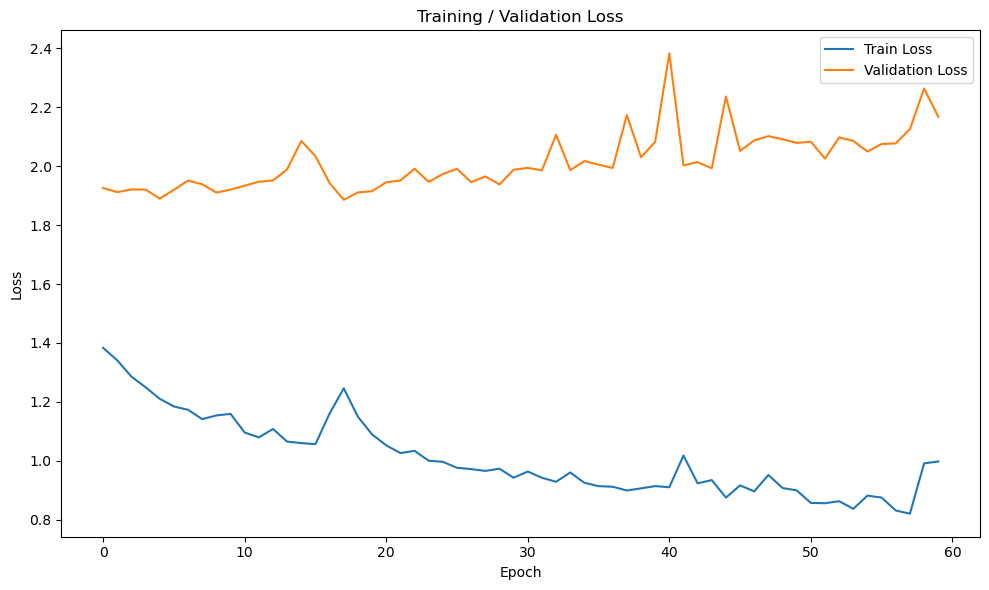

In [184]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = pd.read_csv(best_model_path_dir / "metrics.csv")
ax.plot(metrics_df["train_loss"], label="Train Loss")
ax.plot(metrics_df["val_loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training / Validation Loss")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "training_loss_plot.png", dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)



## plot loss curves (step train VS step val)

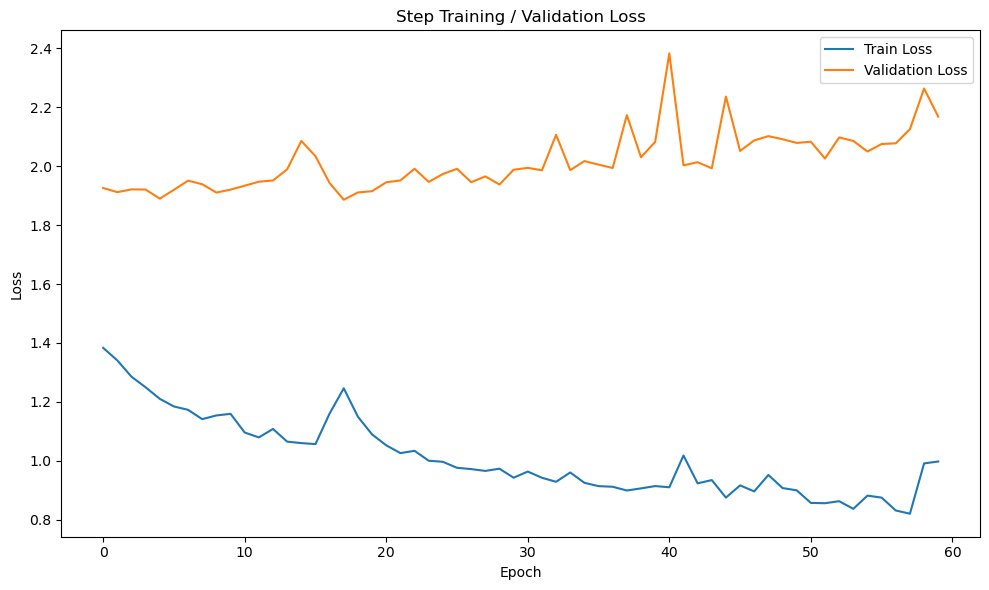

In [185]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = pd.read_csv(best_model_path_dir / "metrics.csv")
ax.plot(metrics_df["train_step_loss"], label="Train Loss")
ax.plot(metrics_df["val_step_loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Step Training / Validation Loss")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "Step_training_loss_plot.png", dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

## plot loss curves (Mistake train VS step val)

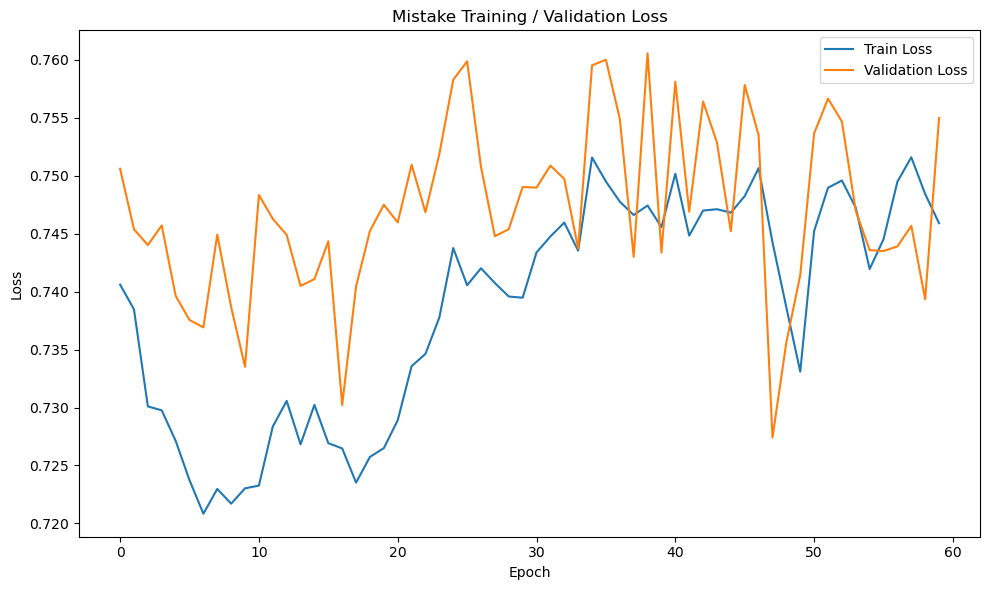

In [186]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = pd.read_csv(best_model_path_dir / "metrics.csv")
ax.plot(metrics_df["train_mistake_loss"], label="Train Loss")
ax.plot(metrics_df["val_mistake_loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Mistake Training / Validation Loss")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "Mistake_training_loss_plot.png", dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

## plot loss curves (progress train VS step val)

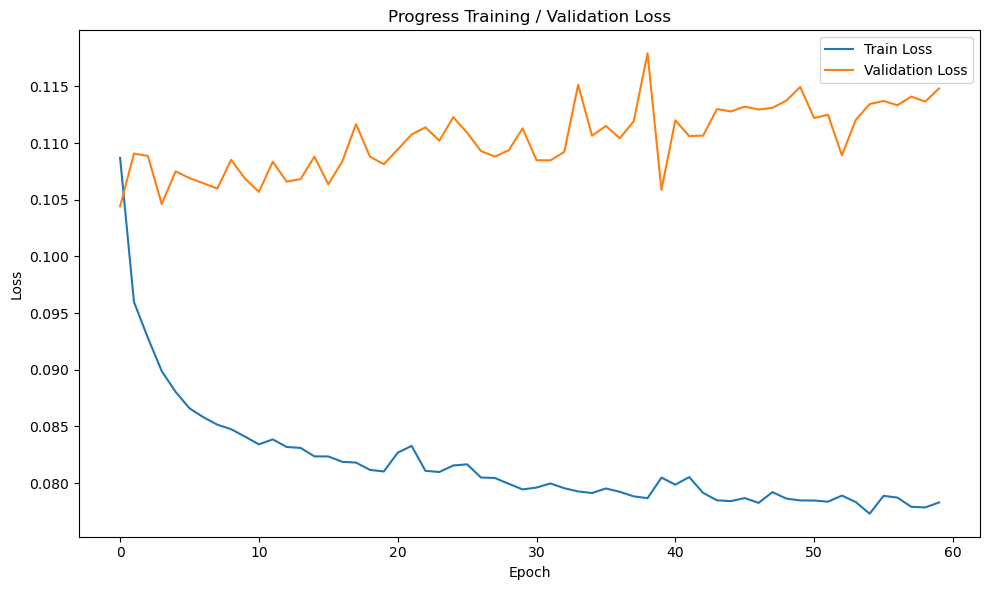

In [149]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = pd.read_csv(best_model_path_dir / "metrics.csv")
ax.plot(metrics_df["train_progress_loss"], label="Train Loss")
ax.plot(metrics_df["val_progress_loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Progress Training / Validation Loss")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "Progress_training_loss_plot.png", dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

In [8]:
import json
best_model_config = best_model_path_dir / "config.json"
best_model_config = json.loads(best_model_config.read_text())
input_dim = best_model_config["input_dim"]
hidden_dim = best_model_config["hidden_dim"]
num_steps = best_model_config["num_steps"]
num_layers = best_model_config.get("num_layers", 1)
dropout = best_model_config.get("dropout", 0.0)
num_mistakes = best_model_config["num_mistakes"]
lambda_mistake = best_model_config["lambda_mistake"]

# Restore the training weights; older runs used ordinary cross entropy.
saved_step_weights = best_model_config.get("step_class_weights")
step_ce_loss = nn.CrossEntropyLoss(
    weight=(torch.tensor(saved_step_weights, dtype=torch.float32, device=device)
            if saved_step_weights is not None else None),
    reduction="none",
)
# step_ce_loss = nn.CrossEntropyLoss()


In [9]:
model_eval = AssistLSTM(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_steps=num_steps,
    dropout=dropout,
    num_layers=num_layers,
    num_mistakes=num_mistakes
).to(device)

model_eval.load_state_dict(torch.load(best_model_path, map_location=device))

model_eval.eval()

AssistLSTM(
  (lstm): LSTM(89, 64, batch_first=True)
  (shared): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (step_head): Linear(in_features=64, out_features=7, bias=True)
  (progress_head): Linear(in_features=64, out_features=1, bias=True)
  (mistake_head): Linear(in_features=64, out_features=2, bias=True)
)

### Train confusion matrix (best validation checkpoint)

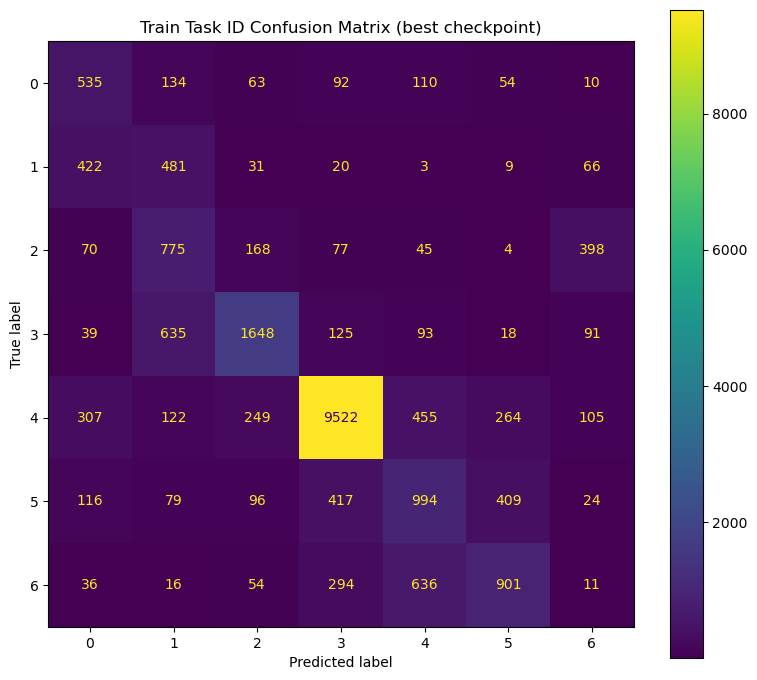

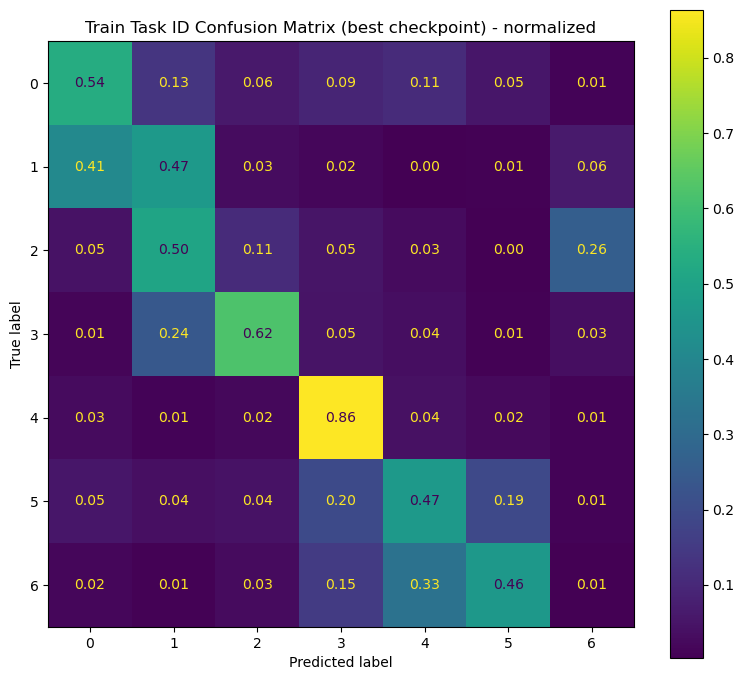

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

# Evaluate all training windows with the best validation checkpoint.
train_true_steps = []
train_pred_steps = []
model_eval.eval()
with torch.no_grad():
    for x, y in loader:
        train_step_logits, _, _ = model_eval(x.to(device))
        train_true_steps.extend(y["step"].cpu().tolist())
        train_pred_steps.extend(train_step_logits.argmax(dim=1).cpu().tolist())

for normalize, suffix, values_format in [(None, "", "d"), ("true", "_norm", ".2f")]:
    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay.from_predictions(
        train_true_steps,
        train_pred_steps,
        labels=np.arange(num_steps),
        normalize=normalize,
        values_format=values_format,
        cmap=None,
        ax=ax,
    )
    ax.set_title("Train Task ID Confusion Matrix (best checkpoint)"
                 + (" - normalized" if normalize else ""))
    fig.tight_layout()
    fig.savefig(
        best_model_path_dir / f"train_step_confusion_matrix{suffix}.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)


In [ ]:
import pandas as pd
import json

total_loss = 0.0
total_step_loss = 0.0
total_mistake_loss = 0.0
total_mistake_correct = 0
total_progress_loss = 0.0
total_progress_mae = 0.0

total_correct = 0
total_samples = 0

all_rows = []

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_loader):
        x = x.to(device)
        y_step = y["step"].to(device)
        y_progress = y["progress"].to(device)
        y_mistake = y["mistake"].to(device)

        step_logits, progress_pred, mistake_pred = model_eval(x)

        loss_step = step_ce_loss(step_logits, y_step).mean()
        loss_progress = mse_loss(progress_pred, y_progress)
        loss_mistake = ce_loss(mistake_pred, y_mistake)
        #loss = lambda_step * loss_step + lambda_progress * loss_progress + lambda_mistake * loss_mistake
        loss = loss_step

        preds_mistake = mistake_pred.argmax(dim=1)
        preds_step = torch.argmax(step_logits, dim=1)
        progress_mae = torch.mean(torch.abs(progress_pred - y_progress))

        batch_size = x.size(0)

        total_loss += loss.item() * batch_size
        total_step_loss += loss_step.item() * batch_size
        total_progress_loss += loss_progress.item() * batch_size
        total_mistake_loss += loss_mistake.item() * batch_size
        total_mistake_correct += (preds_mistake == y_mistake).sum().item()
        total_progress_mae += progress_mae.item() * batch_size

        total_correct += (preds_step == y_step).sum().item()
        total_samples += batch_size

        # save predictions
        for i in range(batch_size):
            all_rows.append({
                "batch_idx": batch_idx,
                "sample_idx_in_batch": i,
                "true_mistake": int(y_mistake[i].cpu().item()),
                "pred_mistake": int(preds_mistake[i].cpu().item()),
                "true_step": int(y_step[i].cpu().item()),
                "pred_step": int(preds_step[i].cpu().item()),
                "true_progress": float(y_progress[i].cpu().item()),
                "pred_progress": float(progress_pred[i].cpu().item()),
                "progress_abs_error": float(
                    torch.abs(progress_pred[i] - y_progress[i]).cpu().item()
                ),
            })

test_loss = total_loss / total_samples
test_step_loss = total_step_loss / total_samples
test_progress_loss = total_progress_loss / total_samples
test_progress_mae = total_progress_mae / total_samples
test_acc = total_correct / total_samples
test_mistake_loss = total_mistake_loss / total_samples
test_mistake_acc = total_mistake_correct / total_samples

results = {
    "test_loss": test_loss,
    "test_step_loss": test_step_loss,
    "test_progress_loss": test_progress_loss,
    "test_acc": test_acc,
    "test_mistake_loss": test_mistake_loss,
    "test_mistake_acc": test_mistake_acc,
    "test_progress_mae": test_progress_mae,
    "test_progress_mae_percent": test_progress_mae * 100,
}

pred_df = pd.DataFrame(all_rows)

In [153]:
pred_df.to_csv(best_model_path_dir / "test_predictions.csv", index=False)

with open(best_model_path_dir / "test_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("Saved test predictions and results.")

Saved test predictions and results.


### Step prediction

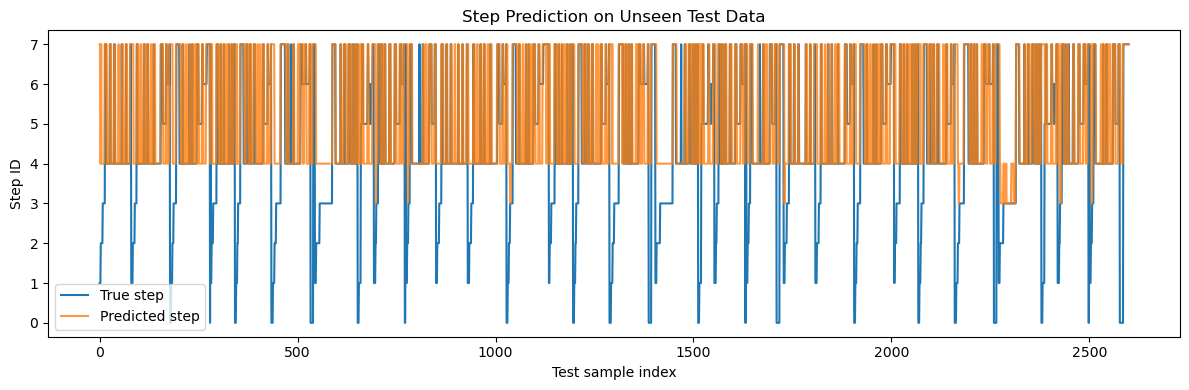

In [154]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(pred_df["true_step"].values, label="True step")
ax.plot(pred_df["pred_step"].values, label="Predicted step", alpha=0.8)

ax.set_xlabel("Test sample index")
ax.set_ylabel("Step ID")
ax.set_title("Step Prediction on Unseen Test Data")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "step_prediction_plot.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

### Progress prediction & error

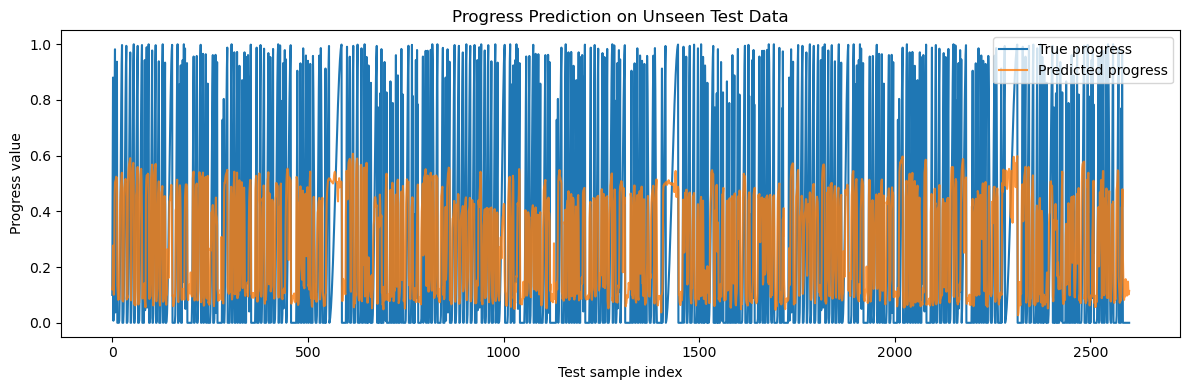

In [155]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pred_df["true_progress"].values, label="True progress")
ax.plot(pred_df["pred_progress"].values, label="Predicted progress", alpha=0.8)

ax.set_xlabel("Test sample index")
ax.set_ylabel("Progress value")

ax.set_title("Progress Prediction on Unseen Test Data")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "progress_prediction_plot.png", dpi=200, bbox_inches="tight")
plt.show()  
plt.close(fig)

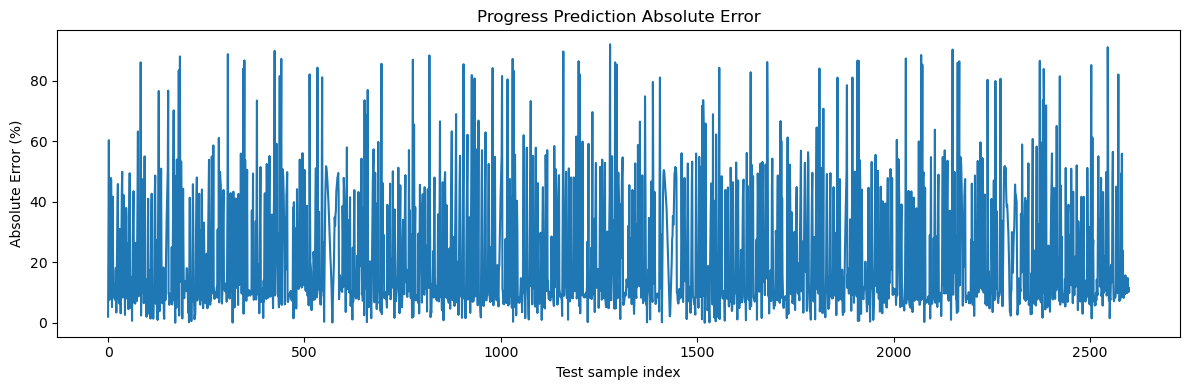

In [156]:
fig, ax  = plt.subplots(figsize=(12, 4))
ax.plot(pred_df["progress_abs_error"].values * 100, label="Absolute Error")
ax.set_xlabel("Test sample index")
ax.set_ylabel("Absolute Error (%)") 

ax.set_title("Progress Prediction Absolute Error")
fig.tight_layout()  
fig.savefig(best_model_path_dir / "progress_prediction_abs_error_plot.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

### step confusion

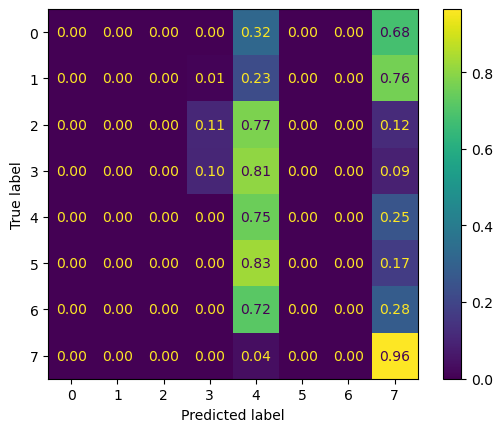

In [157]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    pred_df["true_step"],
    pred_df["pred_step"]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    pred_df["true_step"],
    pred_df["pred_step"],
    normalize="true",
    values_format=".2f"
    )
disp.plot(cmap=None, ax=ax)

ax.set_title("Step Prediction Confusion Matrix")
fig.tight_layout()

fig.savefig(
    best_model_path_dir / "step_prediction_confusion_matrix_norm.png",
    dpi=200,
    bbox_inches="tight"
)

# plt.show()
plt.close(fig)

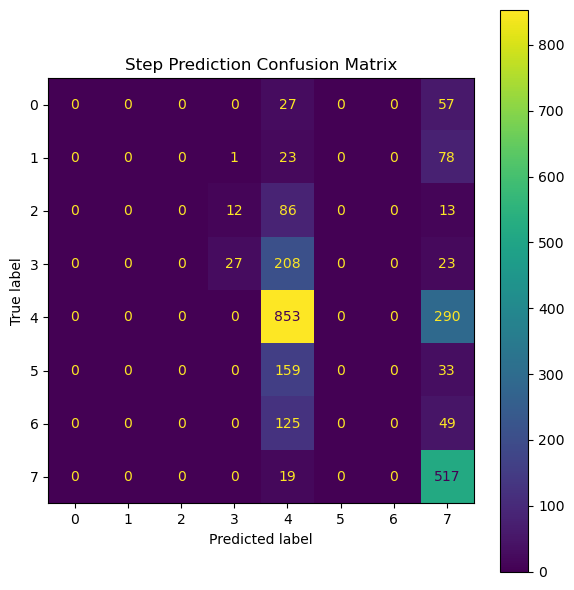

In [158]:
cm = confusion_matrix(
    pred_df["true_step"],
    pred_df["pred_step"]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    cm
    )
disp.plot(cmap=None, ax=ax)

ax.set_title("Step Prediction Confusion Matrix")
fig.tight_layout()

fig.savefig(
    best_model_path_dir / "step_prediction_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

0: "Pull Cables"
1: "Lift"
2: "Align
3: "Screw
4: "Connect Cables"
5: "Clamp Coupling"
6: "Place

### classification report

In [63]:
from sklearn.metrics import classification_report

print(
    classification_report(
        pred_df["true_step"],
        pred_df["pred_step"],
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        84
           1     0.0000    0.0000    0.0000       102
           2     0.0000    0.0000    0.0000       111
           3     0.7843    0.1550    0.2589       258
           4     0.5897    0.7795    0.6714      1143
           5     0.0000    0.0000    0.0000       192
           6     0.0000    0.0000    0.0000       174
           7     0.4942    0.9534    0.6510       536

    accuracy                         0.5546      2600
   macro avg     0.2335    0.2360    0.1977      2600
weighted avg     0.4389    0.5546    0.4551      2600



c:\Users\loy49\anaconda3\envs\yolo_lstm\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\loy49\anaconda3\envs\yolo_lstm\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\loy49\anaconda3\envs\yolo_lstm\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 